In [27]:
import  pandas as pd

df = pd.read_csv("twitter_training.csv",header=None)
df.columns = ["ID","Topic","Sentiment","Text"]
print(df.shape)
print(df.head())
print(df.columns)

(74682, 4)
     ID        Topic Sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                Text  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
Index(['ID', 'Topic', 'Sentiment', 'Text'], dtype='object')


In [28]:
print(df.isnull().sum())
df = df.dropna(subset=["Text"])
print(df.shape)
print(df["Sentiment"].value_counts())

ID             0
Topic          0
Sentiment      0
Text         686
dtype: int64
(73996, 4)
Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64


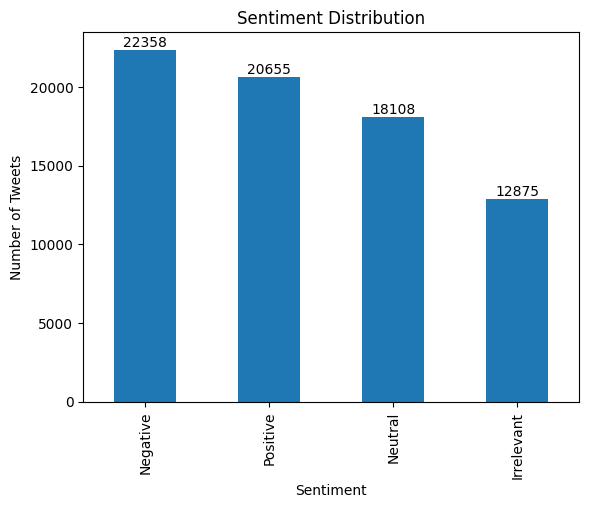

In [29]:
import matplotlib.pyplot as plt

counts = df["Sentiment"].value_counts()

ax = counts.plot(kind="bar")

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")

for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.show()

In [30]:
sentiment_by_topic = pd.crosstab(df["Topic"], df["Sentiment"])
print(sentiment_by_topic.head())

Sentiment       Irrelevant  Negative  Neutral  Positive
Topic                                                  
Amazon                 186       575     1207       308
ApexLegends            192       591      936       634
AssassinsCreed         264       375      156      1439
Battlefield            915       464      351       586
Borderlands            240       426      597      1017


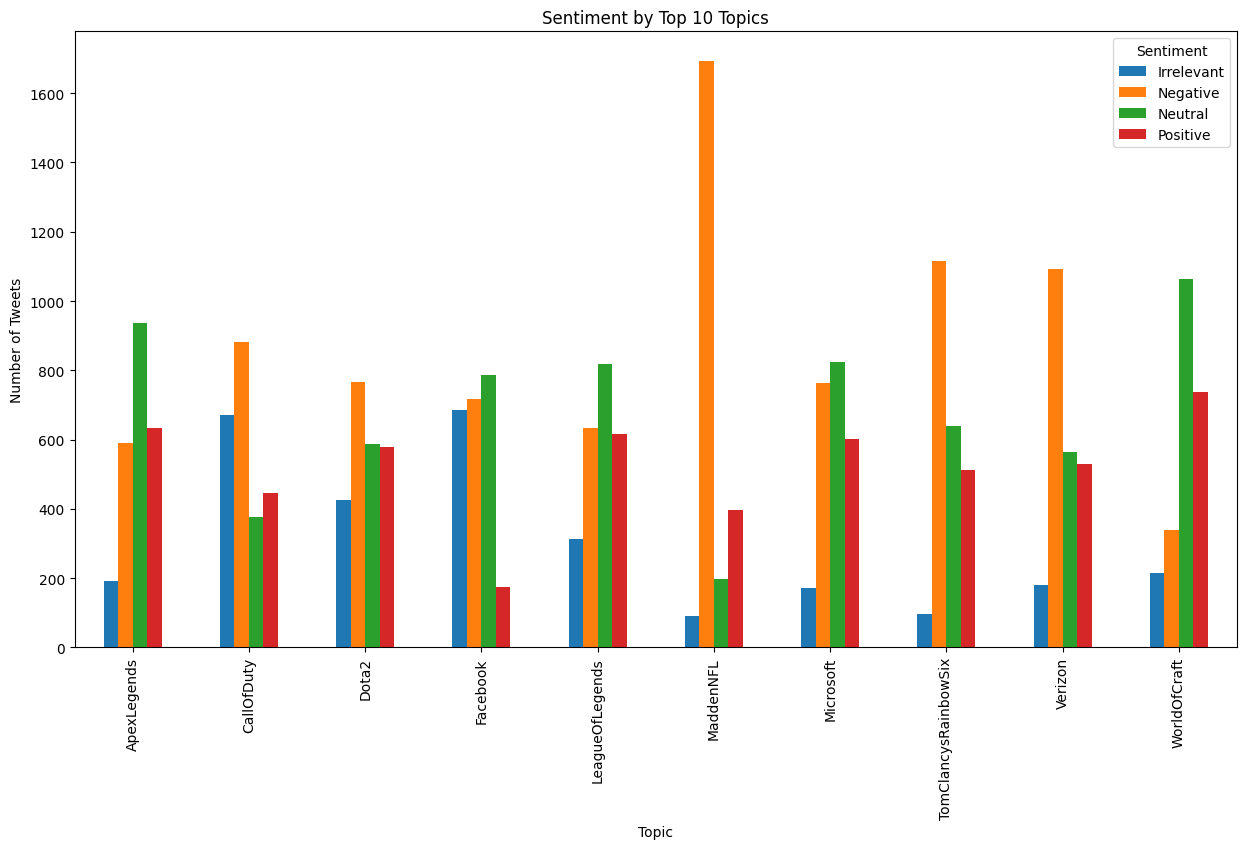

In [31]:
top_topics = df["Topic"].value_counts().head(10).index
filtered_df = df[df["Topic"].isin(top_topics)]

sentiment_by_topic = pd.crosstab(filtered_df["Topic"], filtered_df["Sentiment"])

sentiment_by_topic.plot(kind="bar", figsize=(15,8))
plt.title("Sentiment by Top 10 Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Tweets")
plt.show()

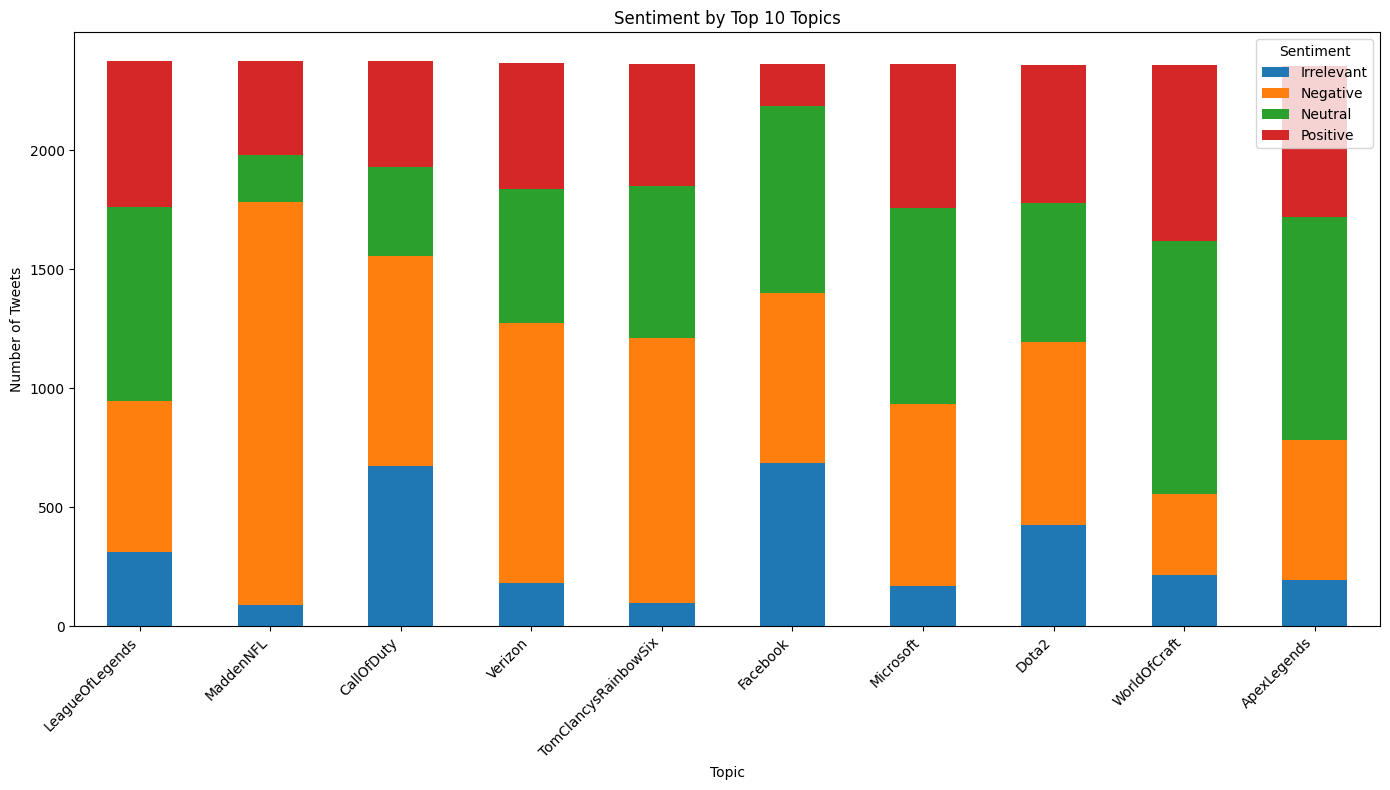

In [32]:
top_topics = df["Topic"].value_counts().head(10).index
filtered_df = df[df["Topic"].isin(top_topics)]

sentiment_by_topic = pd.crosstab(filtered_df["Topic"], filtered_df["Sentiment"])
sentiment_by_topic = sentiment_by_topic.loc[top_topics]

sentiment_by_topic.plot(kind="bar", stacked=True, figsize=(14, 8))

plt.title("Sentiment by Top 10 Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

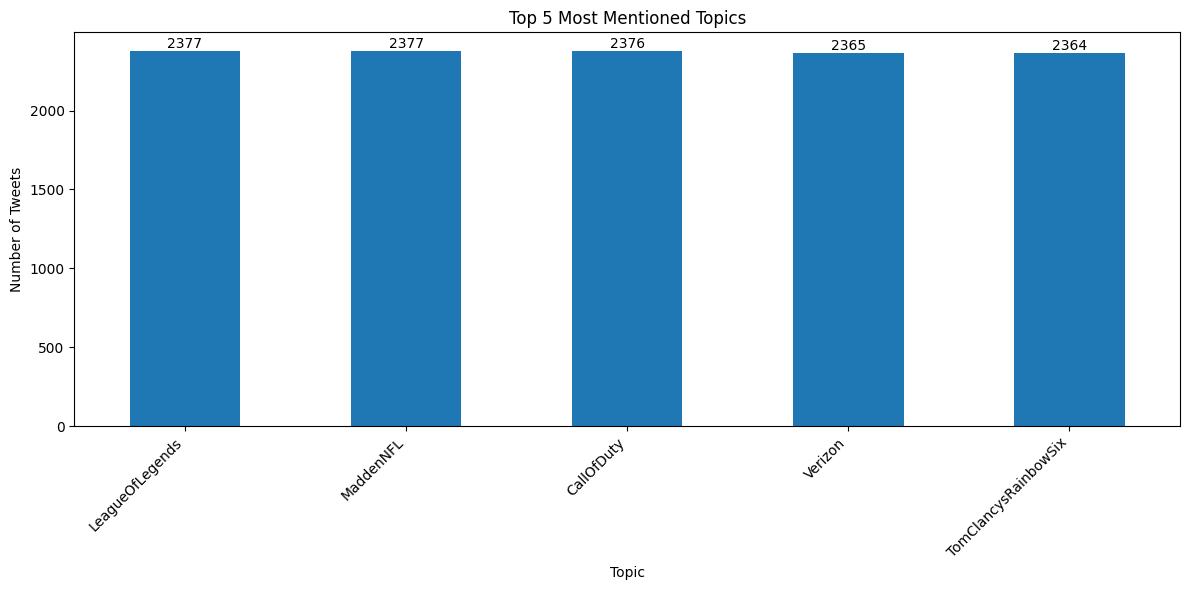

In [34]:
top_topic_counts = df["Topic"].value_counts().head(5)

ax = top_topic_counts.plot(kind="bar", figsize=(12,6))
plt.title("Top 5 Most Mentioned Topics")
plt.xlabel("Topic")
plt.ylabel("Number of Tweets")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(top_topic_counts):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

Topic
AssassinsCreed            1439
Borderlands               1016
Cyberpunk2077              950
PlayStation5(PS5)          936
RedDeadRedemption(RDR)     927
Name: count, dtype: int64


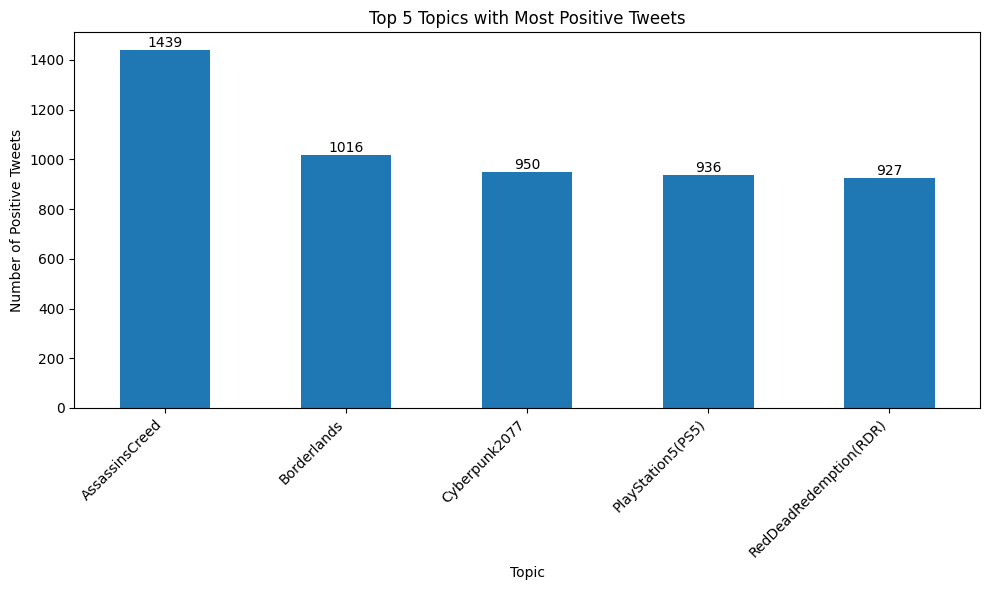

In [24]:
positive_topics = df[df["Sentiment"] == "Positive"]["Topic"].value_counts().head(5)
print(positive_topics)
ax = positive_topics.plot(kind="bar", figsize=(10,6))

plt.title("Top 5 Topics with Most Positive Tweets")
plt.xlabel("Topic")
plt.ylabel("Number of Positive Tweets")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(positive_topics):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

Topic
MaddenNFL               1694
NBA2K                   1469
FIFA                    1169
TomClancysRainbowSix    1115
Verizon                 1092
Name: count, dtype: int64


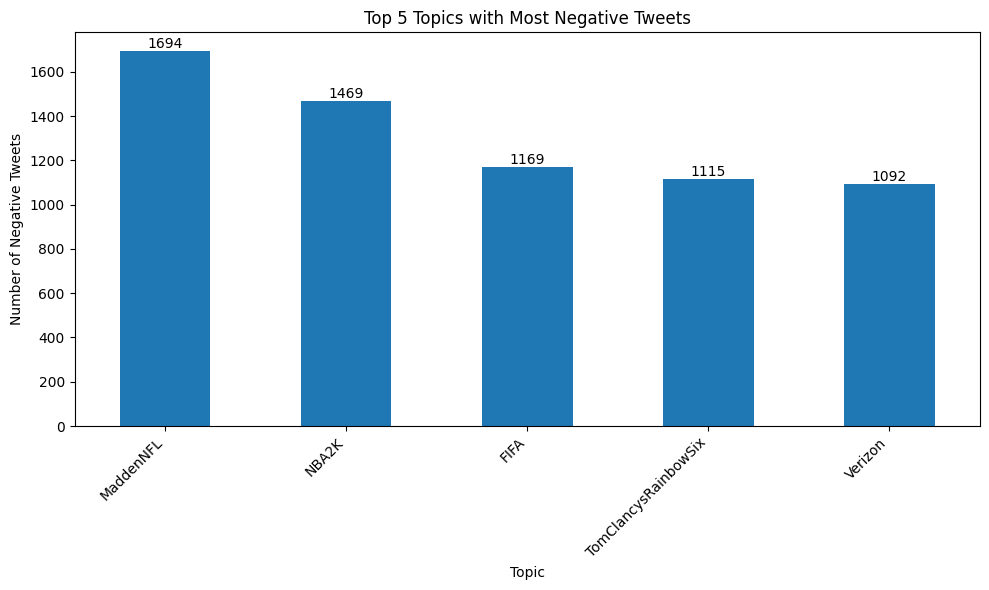

In [25]:
negative_topics = df[df["Sentiment"] == "Negative"]["Topic"].value_counts().head(5)
print(negative_topics)
ax = negative_topics.plot(kind="bar", figsize=(10,6))

plt.title("Top 5 Topics with Most Negative Tweets")
plt.xlabel("Topic")
plt.ylabel("Number of Negative Tweets")
plt.xticks(rotation=45, ha="right")

for i, v in enumerate(negative_topics):
    ax.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()

## Conclusion

This project analyzed sentiment patterns in social media data to understand public opinion toward different topics and brands.

The results showed that **Negative sentiment was the most common**, followed by **Positive** and **Neutral**, while **Irrelevant** appeared the least. This suggests that the overall tone of the dataset was slightly more negative than positive.

The topic-based analysis also showed that sentiment differs across topics. Some topics received more positive reactions, while others received stronger negative opinions. For example, **AssassinsCreed** had the highest number of positive tweets, while **MaddenNFL** had the highest number of negative tweets. In addition, the most discussed topics included **LeagueOfLegends, MaddenNFL, CallOfDuty, Verizon,** and **TomClancysRainbowSix**.

Overall, the visualizations provided a clear view of sentiment distribution and topic-specific public opinion.